The set up area

In [1]:
import duckdb

from pathlib import Path

import matplotlib as plot


In [2]:
duckdb_path = "Data/sakila.duckdb"
Path(duckdb_path).unlink(missing_ok=True)
with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila.sql") as ingest_scripts: 
    conn.sql(ingest_scripts.read())
    
    descrition = conn.sql("DESC;").df()
    films = conn.sql("FROM film;").df()
    actors = conn.sql("FROM actor;").df()
    film_actors = conn.sql("FROM film_actor").df()
    customers = conn.sql("FROM customer;").df()
    payments = conn.sql("FROM payment;").df()
    

task 1a) Movie length over 3h + task 1f) shortest movies

In [ ]:
#over 3h length
duckdb.sql("""--sql
           SELECT title,
           length 
           FROM films
           WHERE length > 180
           ORDER BY length DESC
           LIMIT 15
           """) 

           

In [ ]:
#shorter than 1h
duckdb.sql("""--sql
           SELECT title,
           length
           FROM films
           WHERE length < 60
           ORDER BY length ASC
           LIMIT 10
           """)

task 1b) Movies with Love in title + task 1f) Movies with Hate in title

In [ ]:
duckdb.sql("""--sql
           SELECT title,
           rating,
           length,
           description,
           FROM films
           WHERE 
           title LIKE '%LOVE'
            """)

In [ ]:
duckdb.sql("""--sql
           SELECT title,
           rating,
           length,
           description
           FROM films
           WHERE
           title LIKE '%HATE'
           """)

1c) Avarage movie length

In [ ]:
duckdb.sql("""--sql
           SELECT 
           MIN (length) AS Short_movie,
           MAX (length) AS Long_movie,
           AVG (length) AS avg_movie_length,
           MEDIAN (length) AS median_movie
           FROM films""")

1d) top 10 expensive rental + 1f) top 10 cheapest 

In [ ]:
duckdb.sql("""--sql
           SELECT title,
           rental_rate,
           rental_duration
           FROM films
           ORDER BY rental_rate DESC
           LIMIT 10""")

In [ ]:
duckdb.sql("""--sql
           SELECT title,
           rental_rate,
           rental_duration
           FROM films
           ORDER BY rental_rate ASC
           LIMIT 10""")

1e) most movies for one actor + 1f) the least movies for one actor

In [ ]:
films_joined = duckdb.sql("""--sql
                          SELECT *
                          FROM films f
                          LEFT JOIN film_actors fa ON f.film_id = fa.film_id
                          LEFT JOIN actors a ON a.actor_id = fa.actor_id""").df()

films_joined #checking to make sure it all worked

In [ ]:
duckdb.sql("""--sql
           SELECT 
           actor_id,
           first_name,
           last_name,
           COUNT(*) AS number_films
           FROM 
           films_joined
           GROUP BY 
           first_name,
           actor_id, 
           last_name
           ORDER BY number_films DESC
           LIMIT 10
           """)

In [ ]:
duckdb.sql("""--sql
           SELECT
           actor_id,
           first_name,
           last_name,
           COUNT(*) AS number_films
           FROM
           films_joined
           GROUP BY 
           first_name,
           last_name,
           actor_id
           ORDER BY number_films ASC
           LIMIT 10""")

# TASK 2 AREA

In [3]:
customer_spend = duckdb.sql("""--sql
           SELECT *
           FROM customers c
           LEFT JOIN payments p ON c.customer_id = p.customer_id
           """).df()


In [5]:
amounts_spent = duckdb.sql("""--sql
           SELECT
           customer_id,
           amount,
           COUNT(*) AS money_spent
           FROM
           customer_spend
           GROUP BY
           customer_id,
           amount
           ORDER BY money_spent DESC
            """).df()

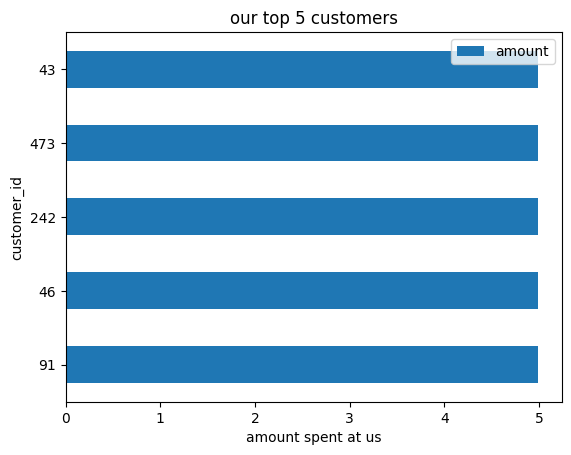

In [6]:
ax = amounts_spent.head(5).plot(
    kind ="barh",
    x ="customer_id",
    y = "amount",
    title = "our top 5 customers",
    xlabel = "amount spent at us")
ax.invert_yaxis()